# Semiconductor Failure Prediction using SVM

This notebook implements a machine learning pipeline to predict semiconductor manufacturing failures using the SECOM dataset. We will compare two dimensionality reduction techniques (PCA vs. Feature Selection) before training a Support Vector Machine (SVM).

## Phase 1: Data Ingestion and EDA

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paresh2047/uci-semcom")

print("Path to dataset files:", path)

100%|██████████| 2.03M/2.03M [00:01<00:00, 1.38MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/paresh2047/uci-semcom/versions/1


In [8]:
!pip install imbalanced-learn kagglehub
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# 1. Download dataset using your kagglehub snippet
dataset_folder = kagglehub.dataset_download("paresh2047/uci-semcom")
print("Downloaded dataset to:", dataset_folder)

# 2. Tell pandas to read the CSV file located inside that new folder
csv_file_path = os.path.join(dataset_folder, 'uci-secom.csv')
df = pd.read_csv(csv_file_path)

# 3. Clean up the Kaggle-specific formatting
# Drop 'Time' since it is a timestamp, not a sensor reading
if 'Time' in df.columns:
    df = df.drop('Time', axis=1)

# Rename 'Pass/Fail' to 'Target' to match the rest of our notebook
if 'Pass/Fail' in df.columns:
    df = df.rename(columns={'Pass/Fail': 'Target'})

# (Optional) Move 'Target' to the very end of the dataframe
if 'Target' in df.columns:
    target_col = df.pop('Target')
    df.insert(len(df.columns), 'Target', target_col)

print(f'\nDataset Shape: {df.shape}')
print('Target Distribution (-1 = Pass, 1 = Fail):')
print(df['Target'].value_counts())
display(df.head())


Using Colab cache for faster access to the 'uci-semcom' dataset.
Downloaded dataset to: /kaggle/input/uci-semcom

Dataset Shape: (1567, 591)
Target Distribution (-1 = Pass, 1 = Fail):
Target
-1    1463
 1     104
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Target
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


## Phase 2: Data Preprocessing
Handling missing values, dropping constant features, scaling, and balancing classes.

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df.drop('Target', axis=1)
y = df['Target']

# 1. Drop features with > 50% missing values
missing_percentages = X.isnull().mean() * 100
cols_to_drop = missing_percentages[missing_percentages > 50].index
X = X.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns due to > 50% missingness.')
print(f'New dimensions: {X.shape}\n')

# 2. Drop constant features (zero variance)
constant_filter = X.nunique() == 1
cols_to_drop_const = constant_filter[constant_filter].index
X = X.drop(columns=cols_to_drop_const)
print(f'Dropped {len(cols_to_drop_const)} constant columns.')
print(f'New dimensions: {X.shape}\n')

# 3. Train-Test Split (Stratified!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Imputation (Median)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# 5. Scaling (Mandatory for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# 6. SMOTE (Address Class Imbalance on Training Data ONLY)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f'Training labels after SMOTE: ')
print(y_train_res.value_counts())

Dropped 28 columns due to > 50% missingness.
New dimensions: (1567, 562)

Dropped 116 constant columns.
New dimensions: (1567, 446)

Training labels after SMOTE: 
Target
-1    1170
 1    1170
Name: count, dtype: int64


## Phase 3: Dimensionality Reduction
We will create two separate training sets: one reduced using **PCA**, and one reduced using **Feature Selection (Random Forest)**.

In [11]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

### APPROACH A: PCA
# We aim to explain 95% of the variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_res)
X_test_pca = pca.transform(X_test_scaled)
print(f'PCA reduced dimensions from {X_train_res.shape[1]} to {X_train_pca.shape[1]} components.\n')

### APPROACH B: Feature Selection (Random Forest Importance)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Let's keep the Top 50 features for comparison
top_k = 50
top_k_indices = indices[:top_k]
X_train_fs = X_train_res[:, top_k_indices]
X_test_fs = X_test_scaled[:, top_k_indices]
print(f'Feature Selection kept the top {top_k} features.')

PCA reduced dimensions from 446 to 149 components.

Feature Selection kept the top 50 features.


## Phase 4: Model Training (SVM)
We train and tune an SVM on both the PCA data and the Feature Selection data.

In [12]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf']
}

print("Tuning SVM on PCA data (Approach A)...")
grid_pca = GridSearchCV(SVC(class_weight='balanced'), param_grid, cv=3, scoring='recall', n_jobs=-1)
grid_pca.fit(X_train_pca, y_train_res)
best_svm_pca = grid_pca.best_estimator_
print(f"Best Parameters (PCA): {grid_pca.best_params_}\n")

print("Tuning SVM on Feature Selected data (Approach B)...")
grid_fs = GridSearchCV(SVC(class_weight='balanced'), param_grid, cv=3, scoring='recall', n_jobs=-1)
grid_fs.fit(X_train_fs, y_train_res)
best_svm_fs = grid_fs.best_estimator_
print(f"Best Parameters (Feature Selection): {grid_fs.best_params_}")

Tuning SVM on PCA data (Approach A)...
Best Parameters (PCA): {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Tuning SVM on Feature Selected data (Approach B)...
Best Parameters (Feature Selection): {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


## Phase 5: Evaluation & Visualization


--- SVM with PCA ---

              precision    recall  f1-score   support

          -1       0.94      1.00      0.97       293
           1       0.50      0.05      0.09        21

    accuracy                           0.93       314
   macro avg       0.72      0.52      0.53       314
weighted avg       0.91      0.93      0.91       314



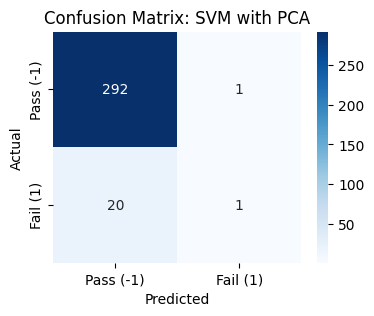

ROC-AUC Score: 0.6654


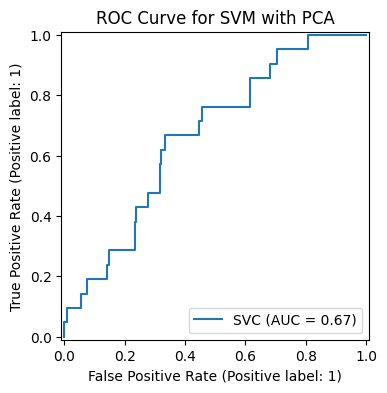


--- SVM with Feature Selection ---

              precision    recall  f1-score   support

          -1       0.94      0.97      0.96       293
           1       0.31      0.19      0.24        21

    accuracy                           0.92       314
   macro avg       0.63      0.58      0.60       314
weighted avg       0.90      0.92      0.91       314



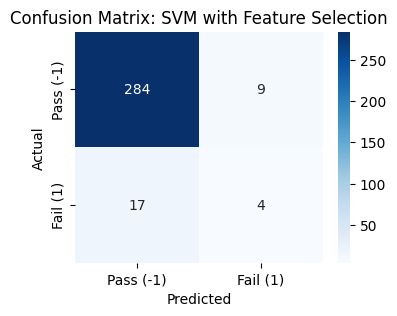

ROC-AUC Score: 0.6982


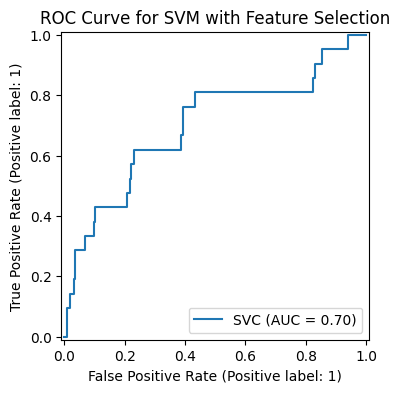

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

def evaluate_model(model, X_test_curr, y_test_curr, title):
    y_pred = model.predict(X_test_curr)
    print(f"\n{'='*40}")
    print(f"--- {title} ---")
    print(f"{'='*40}\n")
    print(classification_report(y_test_curr, y_pred))

    cm = confusion_matrix(y_test_curr, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pass (-1)', 'Fail (1)'],
                yticklabels=['Pass (-1)', 'Fail (1)'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix: {title}')
    plt.show()

    # ROC-AUC calculation
    if hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test_curr)
        auc_score = roc_auc_score(y_test_curr, y_scores)
        print(f"ROC-AUC Score: {auc_score:.4f}")

        # Use from_estimator directly for ROC curve display
        fig, ax = plt.subplots(figsize=(5, 4))
        RocCurveDisplay.from_estimator(model, X_test_curr, y_test_curr, ax=ax)
        plt.title(f'ROC Curve for {title}')
        plt.show()

evaluate_model(best_svm_pca, X_test_pca, y_test, "SVM with PCA")
evaluate_model(best_svm_fs, X_test_fs, y_test, "SVM with Feature Selection")